<a href="https://colab.research.google.com/github/sarbanibhadra/RNN_for_TimeSeries/blob/main/2025AG05587_RNN_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
OVERVIEW

This work implements and compares two approaches for
time series forecasting:
1. LSTM or GRU using Keras/PyTorch
2. Transformer encoder using Keras/PyTorch layers

Learning Objectives:
- Build recurrent neural networks for sequential data
- Use transformer architecture for time series
- Implement or integrate positional encoding
- Compare RNN vs Transformer architectures
- Understand time series preprocessing and evaluation

IMPORTANT:
- Positional encoding MUST be added to transformer
- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
- DO NOT use pre-trained transformers (HuggingFace, TimeGPT, etc.)
- Use temporal train/test split (NO shuffling)

"""
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import json
import os
import math
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense
import tensorflow as tf

PART 1: DATASET LOADING AND EXPLORATION (Informational)

Instructions:
1. Choose ONE dataset from the allowed list
2. Load and explore the time series data
3. Fill in ALL required metadata fields below
4. Provide justification for your primary metric choice

ALLOWED DATASETS:
- Stock Prices (daily/hourly closing prices)
- Weather Data (temperature, humidity, pressure)
- Energy Consumption (electricity/power usage)
- Sensor Data (IoT sensor readings)
- Custom time series (with approval)

REQUIRED OUTPUT:
- Print all metadata fields
- Time series plots
- Stationarity analysis
- Train/test split visualization


In [ ]:
# ## 1.1 Dataset Selection and Loading
# - TODO: Load your chosen time series dataset - Done
import kagglehub

# Download latest version from Kagglehub
path = kagglehub.dataset_download("leukipp/hourly-stock-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hourly-stock-prices' dataset.
Path to dataset files: /kaggle/input/hourly-stock-prices


In [ ]:
# Inspecting the contents of the downloaded directory
print(os.listdir(path))

['2021']


In [ ]:
# Recursively listing upto 5 files in the downloaded directory to see the CSV files
n_files = 5
counter = 0
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv') and counter <= n_files:
            print(os.path.join(root, file))
            counter += 1

/kaggle/input/hourly-stock-prices/2021/ASPAW.csv
/kaggle/input/hourly-stock-prices/2021/MTL.csv
/kaggle/input/hourly-stock-prices/2021/JOE.csv
/kaggle/input/hourly-stock-prices/2021/DRE.csv
/kaggle/input/hourly-stock-prices/2021/AMSF.csv
/kaggle/input/hourly-stock-prices/2021/IMH.csv


In [ ]:
# Loading the dataset
ticker = 'REXR'
csv_file = os.path.join(path, os.listdir(path)[0], ticker+'.csv')
df = pd.read_csv(csv_file)

# Printing columns to identify correct datetime column
print("DataFrame columns:", df.columns)

# Converting 'date' to datetime and set as index
df['date'] = pd.to_datetime(df['date'], utc=True)
df = df.set_index('date')

# For simplicity, let's use the 'Close' price as our univariate time series
data = df['close'].values.reshape(-1, 1)

# Update n_samples
n_samples = data.shape[0]


# REQUIRED: Fill in these metadata fields
dataset_name = ticker+".csv in Hourly Stock Prices" #"TODO: Enter dataset name- Done"
dataset_source = "KaggleHub: leukipp/hourly-stock-prices" #"TODO: Enter source - Done"
n_samples = n_samples   # TODO: Total number of time steps - Done
n_features = data.shape[1]    # TODO: Number of features (1 for univariate, >1 for multivariate) -Done
sequence_length = 24  # sequence_length is chosen 24 for hourly data  # TODO: Lookback window (10-50) -Done
prediction_horizon = 1  # TODO: Forecast steps ahead (1-10) - Done
problem_type = "time_series_forecasting"
feature_selection="""
close: The close price at which the stock last traded when the market closed for a specific period (e.g., the closing price for an hour). This is the column we are using for your time series analysis.
"""

# Primary metric selection
primary_metric = "RMSE"
metric_justification = """
RMSE is chosen as the primary metric because it is widely used in time series forecasting and is sensitive to large errors, penalizing them more heavily. This makes it a good indicator of overall model performance, especially when large prediction errors are undesirable.
"""

print("\n" + "="*70)
print("DATASET INFORMATION")
print("="*70)
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Features: {n_features}")
print(f"Sequence Length: {sequence_length}")
print(f"Prediction Horizon: {prediction_horizon}")
print(f"Problem Type: {problem_type}")
print(f"Feature Selection: {feature_selection}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DataFrame columns: Index(['ticker', 'name', 'date', 'open', 'high', 'low', 'close',
       'adjusted close', 'volume'],
      dtype='object')

DATASET INFORMATION
Dataset: REXR.csv in Hourly Stock Prices
Source: KaggleHub: leukipp/hourly-stock-prices
Total Samples: 2169
Number of Features: 1
Sequence Length: 24
Prediction Horizon: 1
Problem Type: time_series_forecasting
Feature Selection: 
close: The close price at which the stock last traded when the market closed for a specific period (e.g., the closing price for an hour). This is the column we are using for your time series analysis.

Primary Metric: RMSE
Metric Justification: 
RMSE is chosen as the primary metric because it is widely used in time series forecasting and is sensitive to large errors, penalizing them more heavily. This makes it a good indicator of overall model performance, especially when large prediction errors are undesirable.



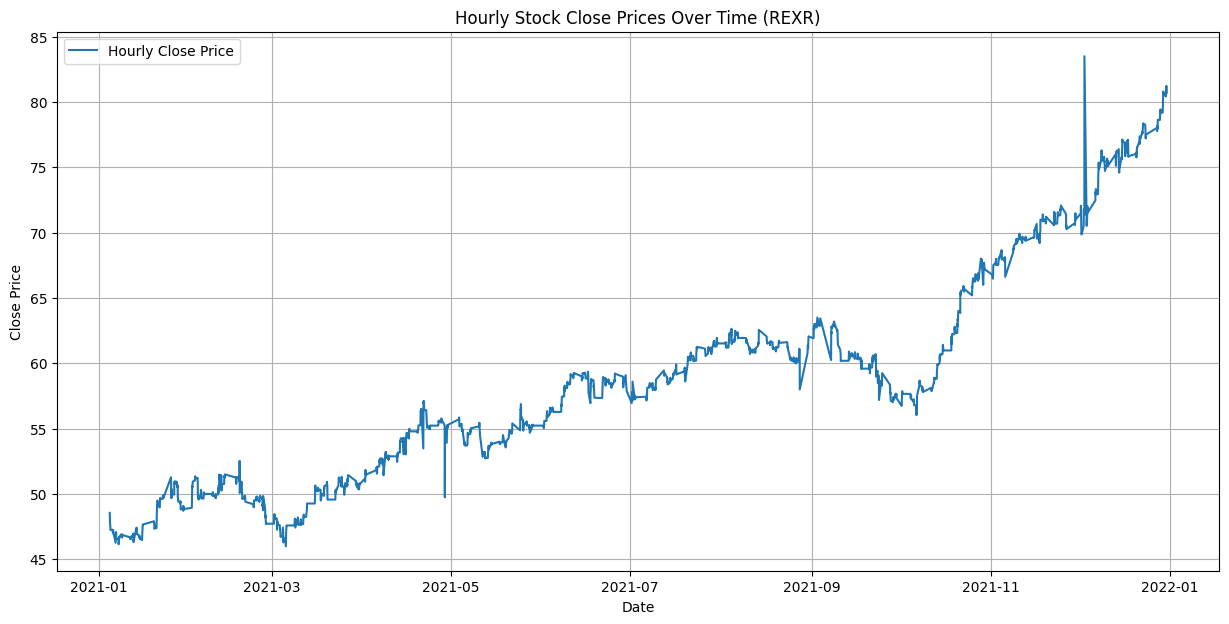

In [ ]:
# ## 1.2 Time Series Exploration
# - TODO: Plot time series data - Done
# - TODO: Check for trends, seasonality - Done
# - TODO: Perform stationarity tests (optional but recommended) - Done

# Plot time series data
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['close'], label='Hourly Close Price')
plt.title('Hourly Stock Close Prices Over Time (REXR)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Check for stationarity (using Augmented Dickey-Fuller test)
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series.flatten())
    print(' ADF Statistic ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
    if result[1] <= 0.05:
        print("Reject the null hypothesis (Ho), data is stationary")
    else:
        print("Fail to reject the null hypothesis (Ho), data is not stationary")

print("\n" + "="*70)
print("Augmented Dickey-Fuller Test on Close Price:")
print("="*70)
adf_test(data)





Augmented Dickey-Fuller Test on Close Price:
 ADF Statistic ADF Statistic: 1.231846
p-value: 0.996199
Critical Values:
	1%: -3.433
	5%: -2.863
	10%: -2.567
Fail to reject the null hypothesis (Ho), data is not stationary



#### Checking for Trends and Seasonality

Although the ADF test showed non-stationarity, we are visually inspecting for trends and seasonality using rolling statistics and seasonal decomposition.

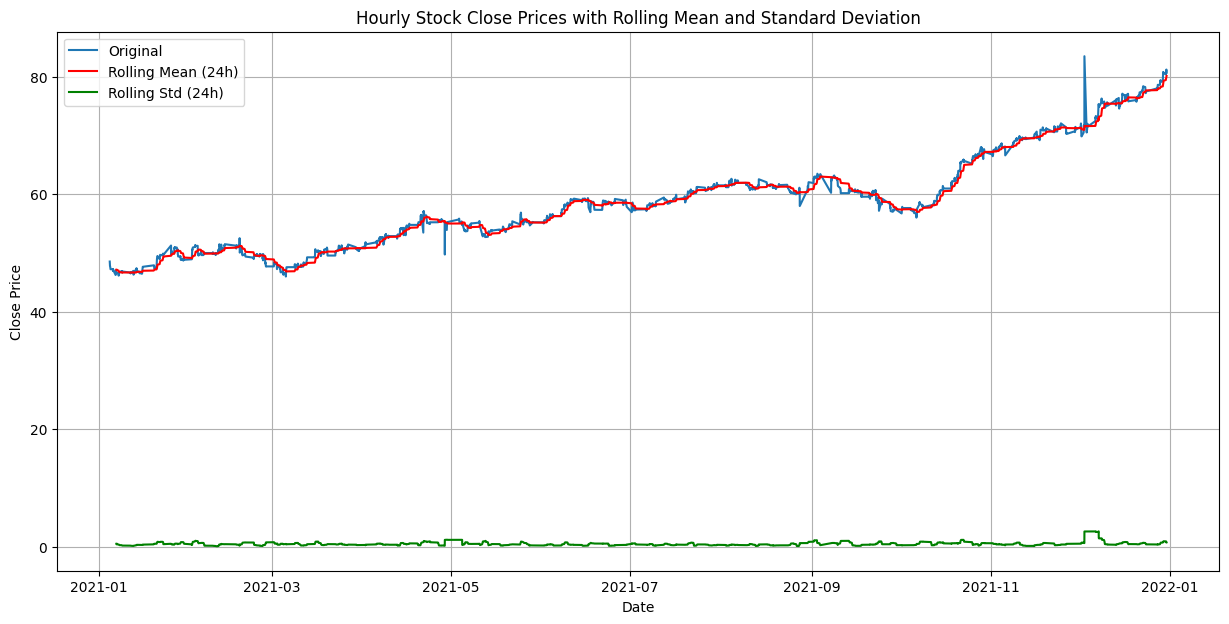

In [ ]:
# Checking for trends, seasonality
# Plotting Rolling Mean and Standard Deviation to identify Trend
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['close'], label='Original')
plt.plot(df.index, df['close'].rolling(window=24).mean(), label='Rolling Mean (24h)', color='red') # 24 hours for daily trend
plt.plot(df.index, df['close'].rolling(window=24).std(), label='Rolling Std (24h)', color='green')
plt.title('Hourly Stock Close Prices with Rolling Mean and Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

The rolling mean shows a clear upward trend, confirming the non-stationarity indicated by the ADF test. The rolling standard deviation appears relatively stable, suggesting that the volatility might not be changing drastically over time.

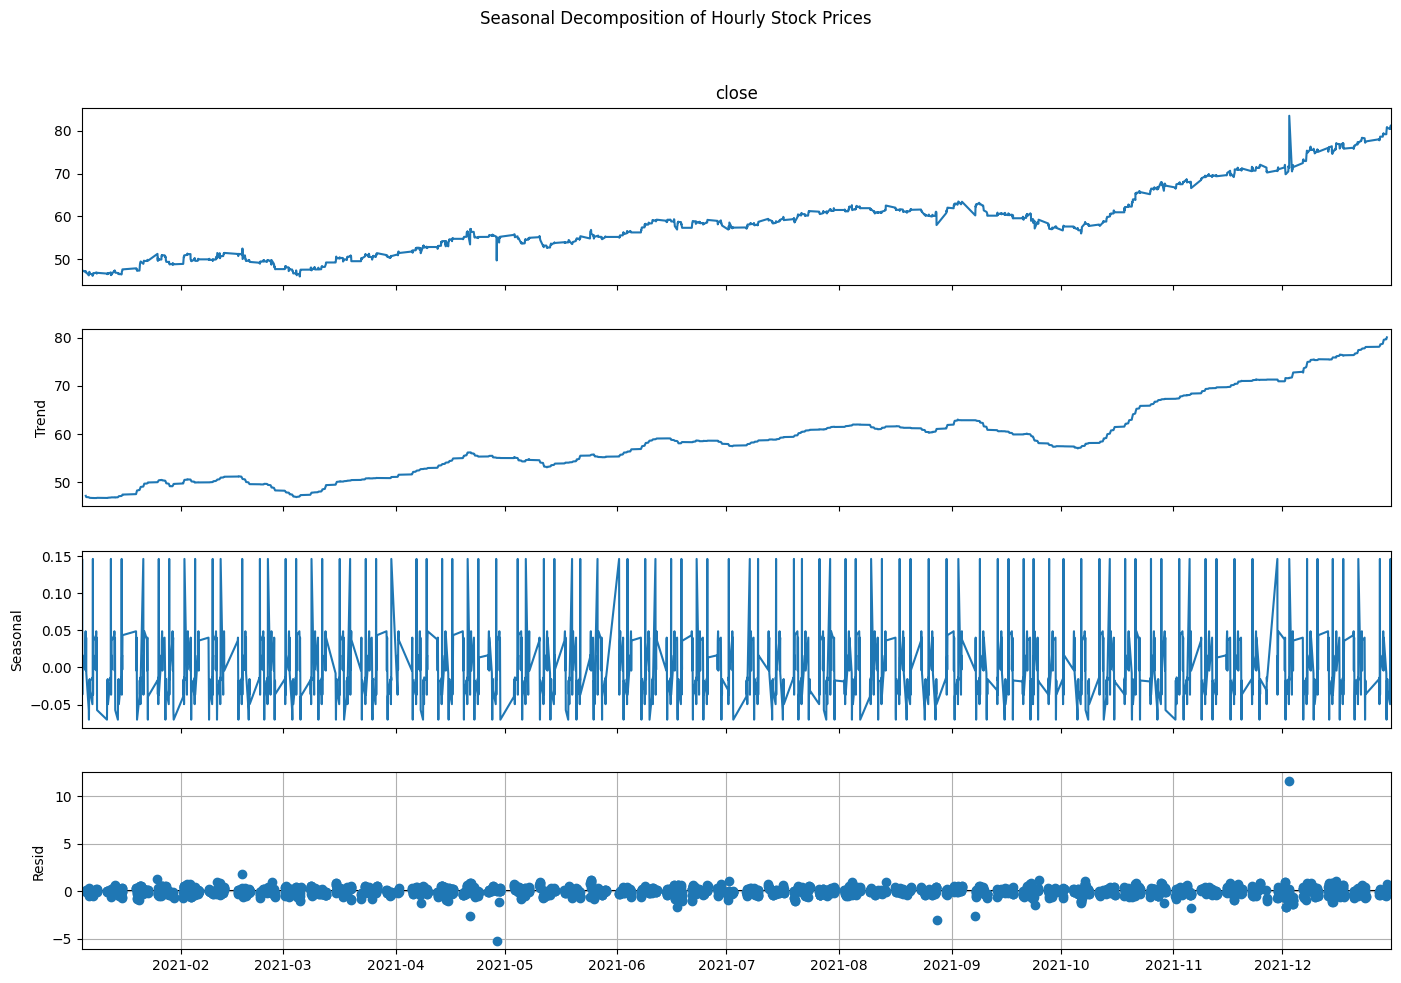

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition
# The frequency (period) is chosen based on the assumed seasonality.
# For hourly data, a daily seasonality would be 24 hours.

if len(df['close']) >= 2 * 24: # Need at least two periods for decomposition
    decomposition = seasonal_decompose(df['close'], model='additive', period=24)
    fig = decomposition.plot()
    fig.set_size_inches(15, 10)
    fig.suptitle('Seasonal Decomposition of Hourly Stock Prices', y=1.02)
    plt.grid(True)
    plt.show()
else:
    print(f"Not enough data points ({len(df['close'])}) for seasonal decomposition with period=24. At least {2*24} required.")

The seasonal decomposition clearly shows an increasing **Trend** component, which aligns with the non-stationary ADF test results and the rolling mean plot. The **Seasonal** component reveals a daily pattern, indicating that stock prices exhibit regular fluctuations within a 24-hour cycle. The **Residual** component represents the irregular or random fluctuations in the data that are not explained by the trend or seasonality.

The Augmented Dickey-Fuller (ADF) test is a statistical test used to determine if a time series is stationary. Here's what the results mean:

Null Hypothesis (H0): The time series has a unit root, meaning it is non-stationary.

Alternative Hypothesis (H1): The time series does not have a unit root, meaning it is stationary.

ADF Statistic (1.231846): This is a negative number. The more negative it is, the stronger the evidence against the null hypothesis (i.e., the more likely the series is stationary).

p-value (0.996199): This is the probability of observing a test statistic as extreme as, or more extreme than, the observed value, assuming the null hypothesis is true. A small p-value (typically less than or equal to 0.05) indicates that you can reject the null hypothesis.

Critical Values: These are specific thresholds at which you can reject the null hypothesis at different significance levels (e.g., 1%, 5%, 10%). If the ADF statistic is less than the critical value, you reject the null hypothesis.

In our case, the ADF Statistic (1.231846) is a positive value, and the p-value (0.996199) is very high (much greater than 0.05). Additionally, the ADF Statistic is not less than any of the critical values. Therefore, we fail to reject the null hypothesis, which means the time series data (Hourly Close Price) is not stationary.

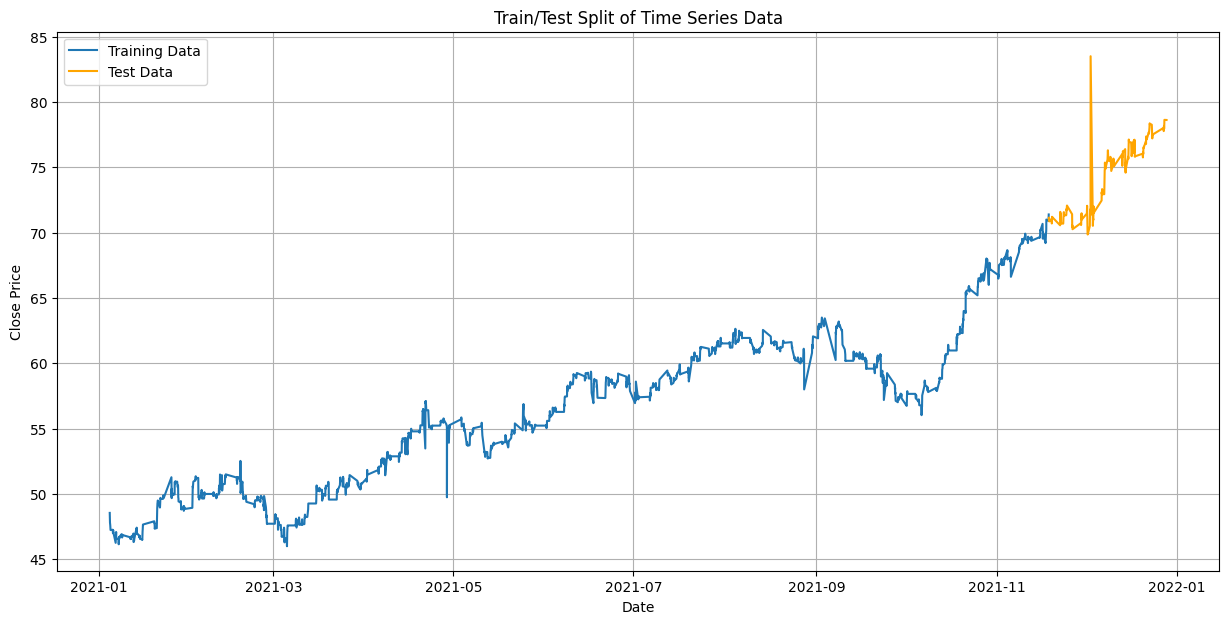

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import json
import os
import math
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense
import tensorflow as tf

# ### 1.3 Data Preprocessing
# - TODO: Preprocess data - Done
# - TODO: Create sequences - Done
scaler = MinMaxScaler(feature_range=(0, 1))
def preprocess_timeseries(data, scaler):
    """
    Preprocess time series data

    Args:
        data: raw time series data
        scaler: scaler object (e.g., MinMaxScaler)

    Returns:
        preprocessed data, scaler
    """
    # TODO: Normalize/standardize data - Done
    scaled_data = scaler.fit_transform(data)

    # TODO: Handle missing values if any - Done
    if np.isnan(scaled_data).any():
        print("\nWarning: Missing values detected. Filling with forward fill (ffill). ")
        # Convert to pandas Series to use ffill, then back to numpy array
        scaled_data = pd.Series(scaled_data.flatten()).ffill().to_numpy().reshape(-1, 1)

    return scaled_data, scaler

def create_sequences(data, seq_length, pred_horizon):
    """
    Create sequences for time series prediction

    Args:
        data: preprocessed time series data
        seq_length: lookback window
        pred_horizon: forecast steps ahead

    Returns:
        X: input sequences, y: target values
    """
    X, y = [], []
    for i in range(len(data) - seq_length - pred_horizon + 1):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length : i + seq_length + pred_horizon])
    return np.array(X), np.array(y)

# Preprocess data
scaled_data, scaler = preprocess_timeseries(data, scaler)

# Create sequences
X, y = create_sequences(scaled_data, sequence_length, prediction_horizon)

# REQUIRED: Temporal train/test split (NO SHUFFLING)
# Split 90/10
train_size = int(len(X) * 0.9)

X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

train_test_ratio = "90/10"
train_samples = len(X_train)
test_samples = len(X_test)

# Visualize train/test split
plt.figure(figsize=(15, 7))
plt.plot(df.index[:len(X_train)], scaler.inverse_transform(X_train[:, 0, 0].reshape(-1, 1)), label='Training Data') # Plotting first element of each sequence for visualization purpose
plt.plot(df.index[len(X_train):len(X_train)+len(X_test)], scaler.inverse_transform(X_test[:, 0, 0].reshape(-1, 1)), label='Test Data', color='orange')
plt.title('Train/Test Split of Time Series Data')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("\n" + "="*70)
print("Train/Test statistics")
print("="*70)
print(f"Train/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print("IMPORTANT: Temporal split used (NO shuffling)")



Train/Test statistics
Train/Test Split: 90/10
Training Samples: 1930
Test Samples: 215
IMPORTANT: Temporal split used (NO shuffling)


PART 2: LSTM/GRU IMPLEMENTATION (5 MARKS)

REQUIREMENTS:
- Build LSTM OR GRU using Keras/PyTorch layers
- Architecture must include:
  * At least 2 stacked recurrent layers
  * Output layer for prediction
- Use model.compile() and model.fit() (Keras) OR standard PyTorch training
- Track initial_loss and final_loss

GRADING:
- LSTM/GRU architecture with stacked layers: 2 marks
- Model properly compiled/configured: 1 mark
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark




In [ ]:
# ### 2.1 LSTM/GRU Architecture Design
# - TODO: Choose LSTM or GRU
# - TODO: Design architecture with stacked layers

from keras.models import Model
from keras.layers import Input

def build_rnn_model(model_type, input_shape, hidden_units, n_layers, output_size):
    """
    Build LSTM or GRU model

    Args:
        model_type: string ('LSTM' or 'GRU')
        input_shape: tuple (sequence_length, n_features)
        hidden_units: number of hidden units per layer
        n_layers: number of stacked layers (minimum 2)
        output_size: prediction horizon

    Returns:
        model: compiled RNN model
    """
    inputs = Input(shape=input_shape) # Define the input layer explicitly
    x = inputs
    for i in range(n_layers):
        return_sequences = True if i < n_layers - 1 else False
        if model_type == 'LSTM':
            x = LSTM(hidden_units, activation='relu', return_sequences=return_sequences)(x)
        elif model_type == 'GRU':
            x = GRU(hidden_units, activation='relu', return_sequences=return_sequences)(x)
    outputs = Dense(output_size)(x)

    model = Model(inputs=inputs, outputs=outputs) # Use the functional API
    return model

# TODO: Create RNN model
rnn_model = build_rnn_model('LSTM', (sequence_length, n_features), 64, 2, prediction_horizon)
rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
# TODO: Compile model
# For Keras: model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# For PyTorch: define optimizer and loss function


# ### 2.2 Train RNN Model

print("\nRNN MODEL TRAINING")
# Track training time
rnn_start_time = time.time()

# +
# Train your model
history = rnn_model.fit(X_train, y_train, epochs=100, batch_size=32) # verbose=0 to suppress output for brevity
# -

rnn_training_time = time.time() - rnn_start_time

# REQUIRED: Track initial and final loss
rnn_initial_loss = history.history['loss'][0]  # Get from training history (first epoch)
rnn_final_loss = history.history['loss'][-1]  # Get from training history (last epoch)

print(f"Training completed in {rnn_training_time:.2f} seconds")
print(f"Initial Loss: {rnn_initial_loss:.4f}")
print(f"Final Loss: {rnn_final_loss:.4f}")



RNN MODEL TRAINING
Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0146 - mae: 0.0746
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8163e-04 - mae: 0.0129
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8011e-04 - mae: 0.0129
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5870e-04 - mae: 0.0121
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5343e-04 - mae: 0.0120
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4118e-04 - mae: 0.0117
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.5672e-04 - mae: 0.0121
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2674e-04 - mae: 0.0113
Epoch 9/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.4504e-04 - mae: 0.0119
Epoch 10/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.2640e-04 - mae: 0.0113
Epoch 11/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.9739e-04 - mae: 0.0104
Epoch 12/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - los

In [ ]:
# ### 2.3 Evaluate RNN Model
# - TODO: Make predictions on test set - Done
# - TODO: Inverse transform if data was normalized - Done
# - TODO: Calculate all 4 required metrics - Done

def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    # Implement MAPE calculation
    # MAPE = mean(|y_true - y_pred| / |y_true|) * 100
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Make predictions on test set
rnn_y_pred_scaled = rnn_model.predict(X_test)

# Inverse transform if data was normalized
rnn_y_pred = scaler.inverse_transform(rnn_y_pred_scaled)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# REQUIRED: Calculate all 4 metrics
rnn_mae = mean_absolute_error(y_test_inv, rnn_y_pred)
rnn_rmse = np.sqrt(mean_squared_error(y_test_inv, rnn_y_pred))
rnn_mape = calculate_mape(y_test_inv, rnn_y_pred)
rnn_r2 = r2_score(y_test_inv, rnn_y_pred)

print("\n" + "="*70)
print("RNN Model Performance:")
print("="*70)
print(f"Train/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print("IMPORTANT: Temporal split used (NO shuffling)")

print(f"MAE:   {rnn_mae:.4f}")
print(f"RMSE:  {rnn_rmse:.4f}")
print(f"MAPE:  {rnn_mape:.4f}%")
print(f"R² Score: {rnn_r2:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step

RNN Model Performance:
Train/Test Split: 90/10
Training Samples: 1930
Test Samples: 215
IMPORTANT: Temporal split used (NO shuffling)
MAE:   0.5927
RMSE:  1.0624
MAPE:  0.7785%
R² Score: 0.8702


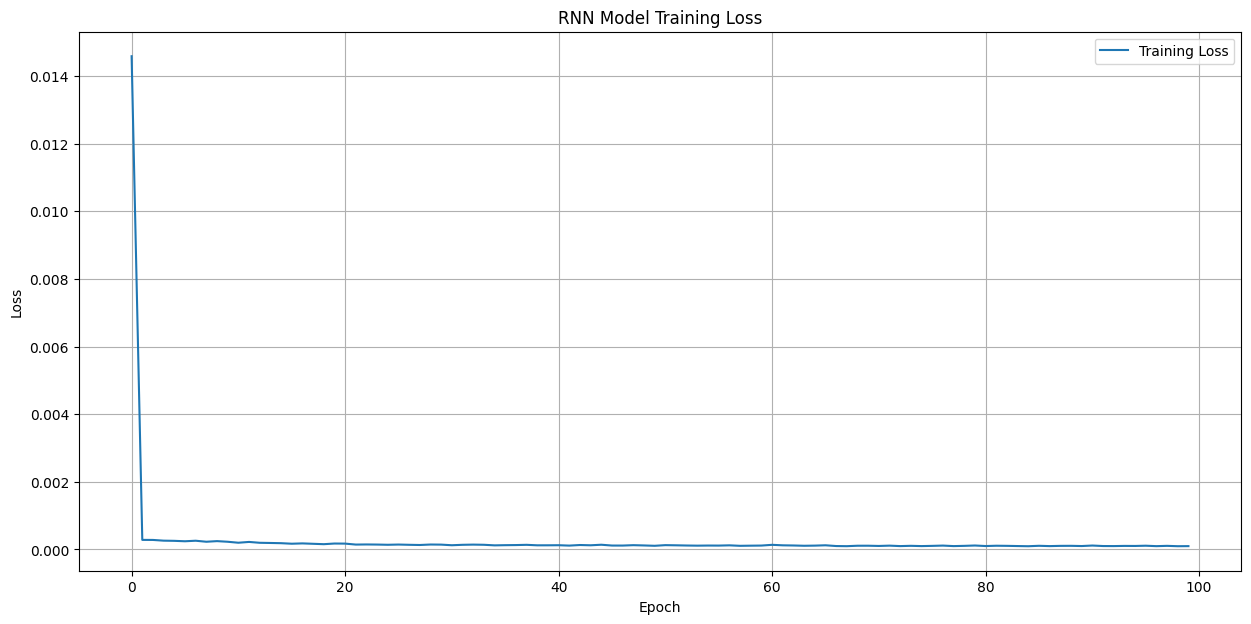

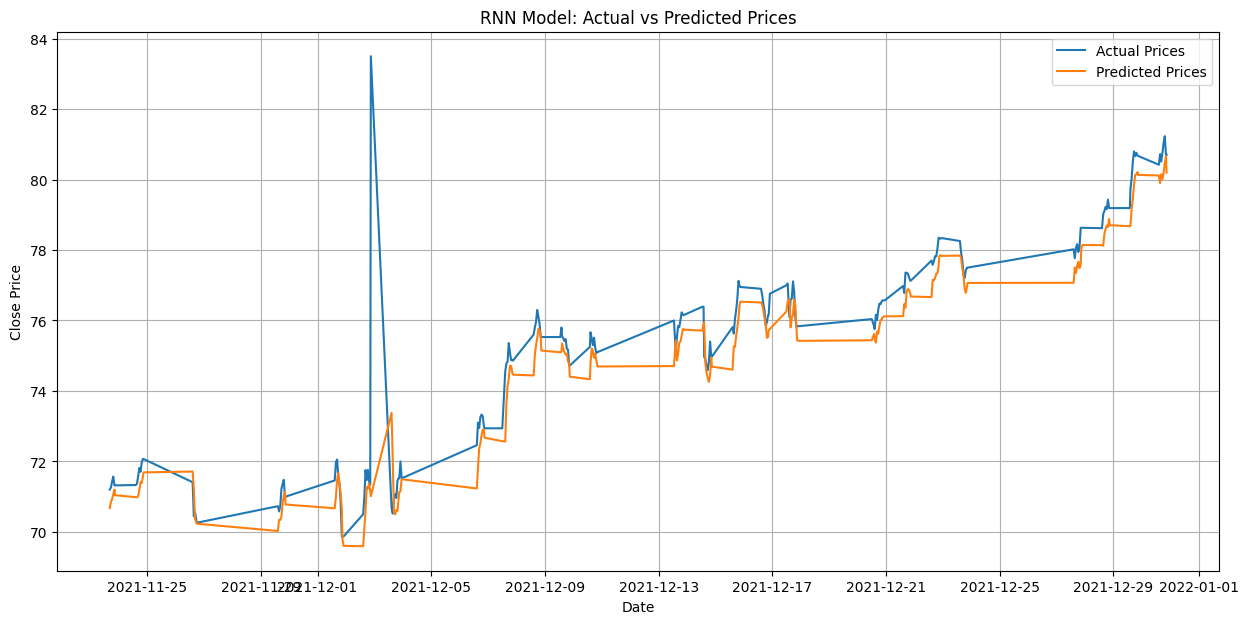

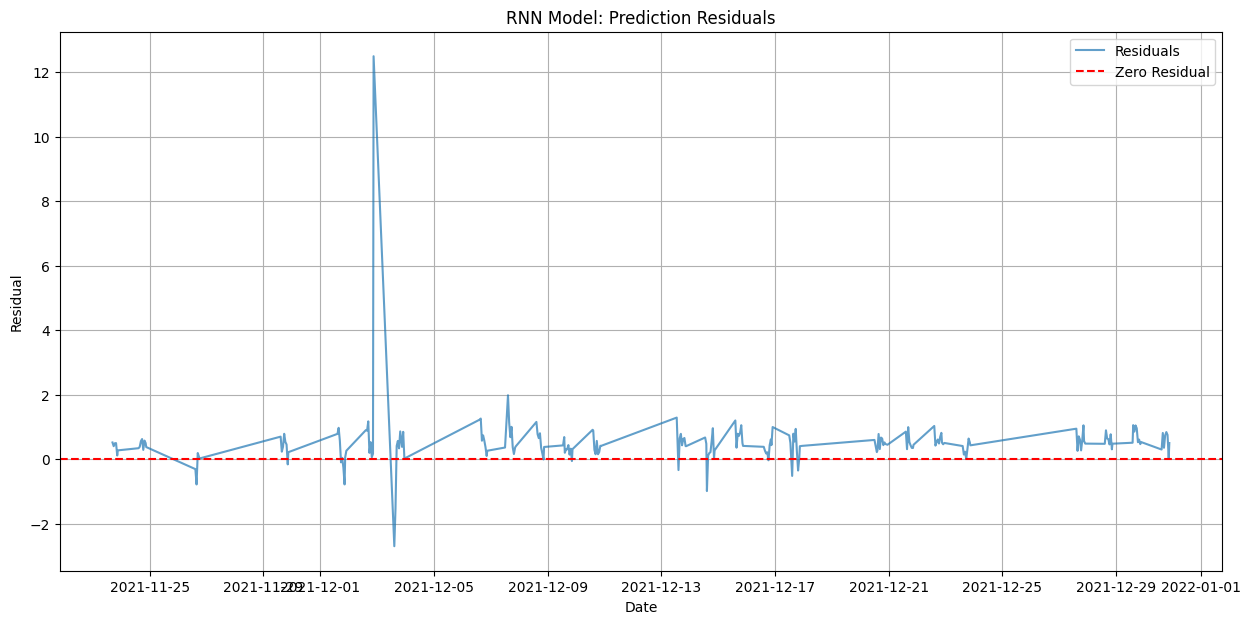

In [ ]:
# ### 2.4 Visualize RNN Results
# - TODO: Plot training loss curve - Done
# - TODO: Plot actual vs predicted values -Done
# - TODO: Plot residuals - Done

# Plot training loss curve
plt.figure(figsize=(15, 7))
plt.plot(history.history['loss'], label='Training Loss')
plt.title('RNN Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot actual vs predicted values
plt.figure(figsize=(15, 7))
plt.plot(df.index[-len(y_test_inv):], y_test_inv, label='Actual Prices')
plt.plot(df.index[-len(rnn_y_pred):], rnn_y_pred, label='Predicted Prices')
plt.title('RNN Model: Actual vs Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot residuals
residuals = y_test_inv - rnn_y_pred
plt.figure(figsize=(15, 7))
plt.plot(df.index[-len(residuals):], residuals, label='Residuals', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residual')
plt.title('RNN Model: Prediction Residuals')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.legend()
plt.grid(True)
plt.show()

PART 3: TRANSFORMER IMPLEMENTATION (5 MARKS)

REQUIREMENTS:
- Build Transformer encoder using Keras/PyTorch layers
- MUST add positional encoding to input:
  * Custom sinusoidal implementation OR
  * Use built-in positional encoding (if framework provides)
- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
- Use standard training methods
- Track initial_loss and final_loss

PROHIBITED:
- Using pre-trained transformers (HuggingFace, TimeGPT, etc.)
- Skipping positional encoding entirely

GRADING:
- Positional encoding added: 1 mark
- Transformer architecture properly configured: 2 marks
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark


In [ ]:
import tensorflow as tf

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, sequence_length, d_model, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.d_model = d_model
        # Use a Keras Embedding layer for positional encodings, it handles trainable=False automatically
        self.position_embedding_layer = tf.keras.layers.Embedding(
            input_dim=sequence_length,
            output_dim=d_model,
            trainable=False
        )

        # Use the provided positional_encoding function to generate the matrix
        position_embedding_matrix = positional_encoding(sequence_length, d_model)

        self.position_embedding_layer.build((None,))
        self.position_embedding_layer.set_weights([position_embedding_matrix])

    def call(self, inputs):
        # inputs has shape (batch_size, sequence_length, d_model)
        # Create a tensor of positions: [0, 1, 2, ..., sequence_length - 1]
        positions = tf.range(start=0, limit=tf.shape(inputs)[1], delta=1)
        # Get positional embeddings for these positions
        positional_embeddings = self.position_embedding_layer(positions)

        # Add positional embeddings to the input embeddings
        return inputs + positional_embeddings

# The original positional_encoding function is not directly used by the Keras Layer implementation above,
# but is kept for reference or if a direct numpy-based PE was desired outside a Keras Layer.
def positional_encoding(seq_length, d_model):
    """
    Generate sinusoidal positional encodings

    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Args:
        seq_length: length of the sequence
        d_model: dimension of the model

    Returns:
        positional encodings: array of shape (seq_length, d_model)
    """
    pe = np.zeros((seq_length, d_model))
    for pos in range(seq_length):
        for i in range(0, d_model, 2):
            pe[pos, i] = math.sin(pos / (10000 ** ((2 * i) / d_model)))
            if i + 1 < d_model:
                pe[pos, i + 1] = math.cos(pos / (10000 ** ((2 * i) / d_model)))
    return pe

In [ ]:
# ###  3.2 Transformer Encoder Architecture
# - Option A: Using Pytorch
# - Option B: Using Keras

# Option B: Using Keras
import keras
from keras import layers
from keras.callbacks import EarlyStopping # Import EarlyStopping

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential(
            [
                layers.Dense(ff_dim, activation="relu"),
                layers.Dense(embed_dim),
            ]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None): # Made training argument optional
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "ff_dim": self.ff_dim,
            "rate": self.rate,
        })
        return config

def build_transformer_model(sequence_length, n_features, d_model, n_heads, n_layers, d_ff, output_size):
    inputs = keras.Input(shape=(sequence_length, n_features))
    # Project n_features to d_model for the transformer input
    x = layers.Dense(d_model)(inputs)
    # Add Positional Encoding
    x = PositionalEmbedding(sequence_length, d_model)(x)

    for _ in range(n_layers):
        x = TransformerBlock(d_model, n_heads, d_ff)(x)

    # Use GlobalAveragePooling1D or Flatten for sequence to vector conversion
    x = layers.Flatten()(x)
    outputs = layers.Dense(output_size)(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# ### 3.3 Build Your Transformer Model

# Create Transformer model
d_model = 64  # Model dimension
n_heads = 4   # Number of attention heads
n_layers_transformer = 2 # Number of transformer blocks
d_ff = 128  # Feed-forward dimension

transformer_model = build_transformer_model(sequence_length, n_features, d_model, n_heads, n_layers_transformer, d_ff, prediction_horizon)

# Compile model
transformer_model.compile(optimizer='adam', loss='mse', metrics=['mae'])


# ### 3.4 Train Transformer Model

print("\nTRANSFORMER MODEL TRAINING")
# Track training time
transformer_start_time = time.time()

# Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)

# Train your model with EarlyStopping and increased epochs
history_transformer = transformer_model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0, callbacks=[early_stopping])

transformer_training_time = time.time() - transformer_start_time

# REQUIRED: Track initial and final loss
transformer_initial_loss = history_transformer.history['loss'][0]
transformer_final_loss = history_transformer.history['loss'][-1]

print(f"Training completed in {transformer_training_time:.2f} seconds")
print(f"Initial Loss: {transformer_initial_loss:.4f}")
print(f"Final Loss: {transformer_final_loss:.4f}")

# ### 3.5 Evaluate Transformer Model
#
# - Make predictions on test set
# - Inverse transform if data was normalized
# - Calculate all 4 required metrics

# Make predictions on test set
transformer_y_pred_scaled = transformer_model.predict(X_test)

# Inverse transform if data was normalized
transformer_y_pred = scaler.inverse_transform(transformer_y_pred_scaled)

# REQUIRED: Calculate all 4 metrics
transformer_mae = mean_absolute_error(y_test_inv, transformer_y_pred)
transformer_rmse = np.sqrt(mean_squared_error(y_test_inv, transformer_y_pred))
transformer_mape = calculate_mape(y_test_inv, transformer_y_pred)
transformer_r2 = r2_score(y_test_inv, transformer_y_pred)

print("\n" + "="*70)
print("Transformer Model Performance:")
print("="*70)
print(f"MAE:   {transformer_mae:.4f}")
print(f"RMSE:  {transformer_rmse:.4f}")
print(f"MAPE:  {transformer_mape:.4f}%")
print(f"R² Score: {transformer_r2:.4f}")


TRANSFORMER MODEL TRAINING
Training completed in 51.36 seconds
Initial Loss: 0.7646
Final Loss: 0.0009
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step

Transformer Model Performance:
MAE:   1.4824
RMSE:  1.8574
MAPE:  1.9339%
R² Score: 0.6033


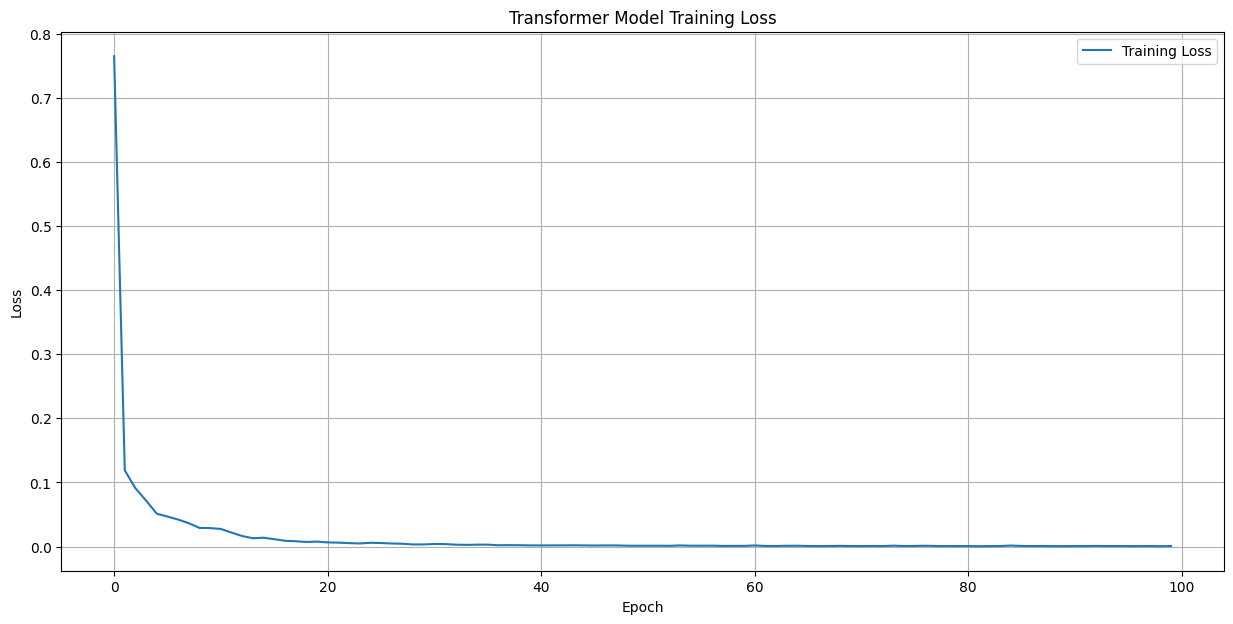

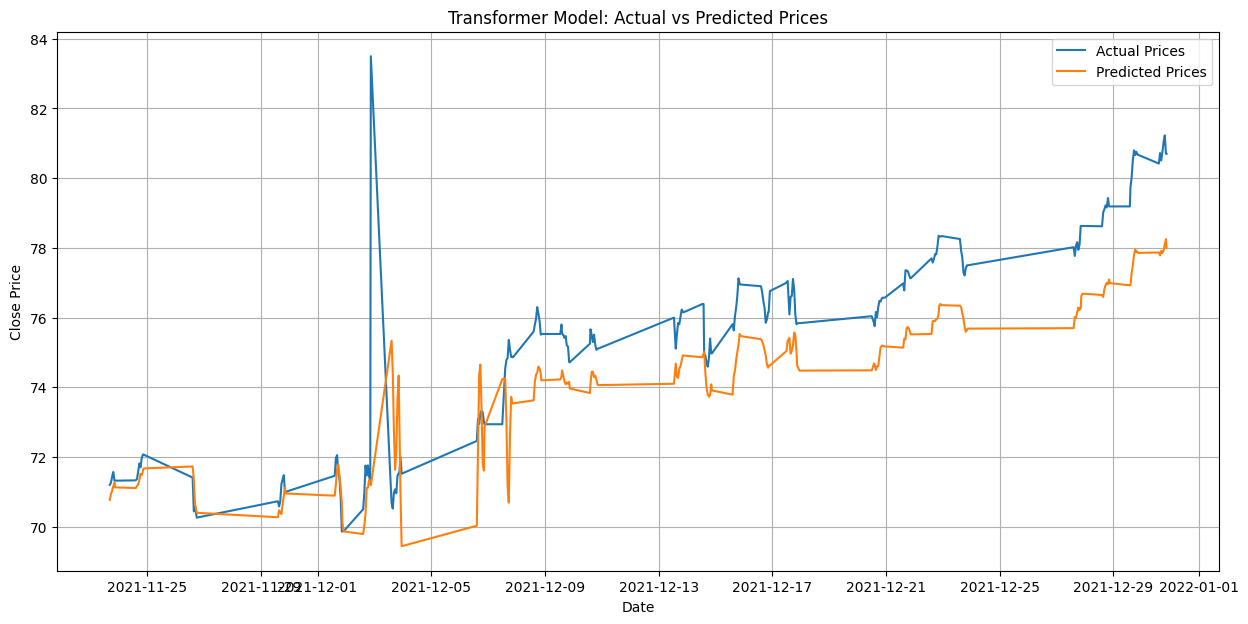

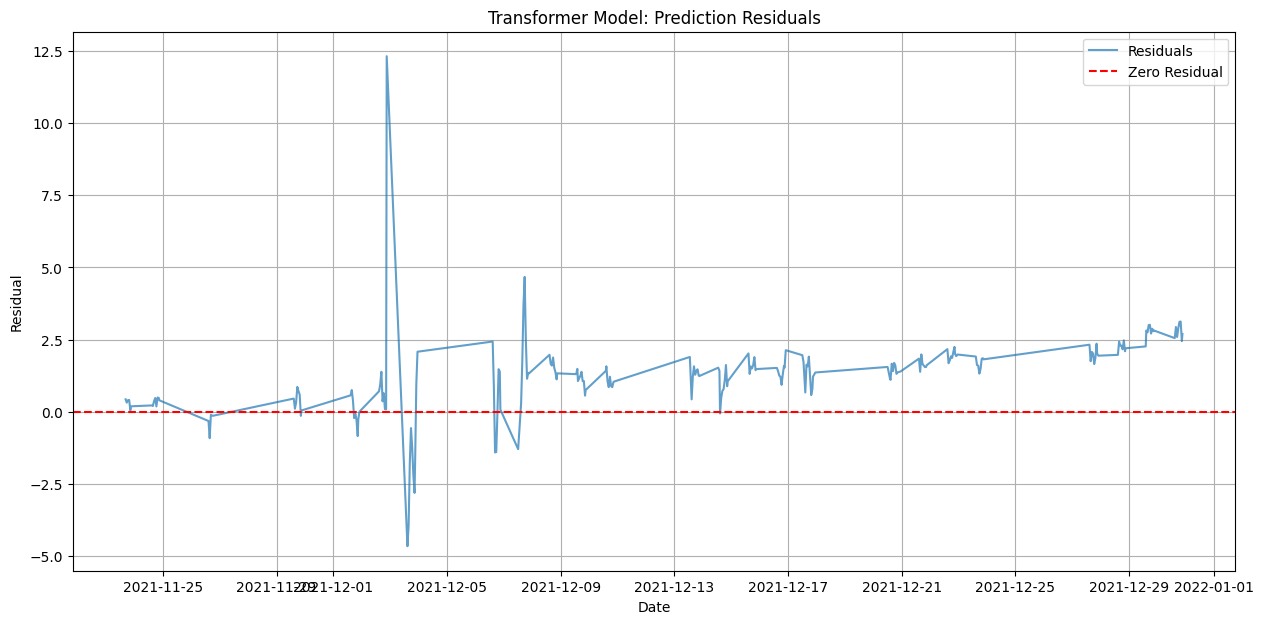

In [ ]:
# ### 3.6 Visualize Transformer Results
# - Plot training loss curve
# - Plot actual vs predicted values
# - Plot attention weights (optional but informative)

# Plot training loss curve
plt.figure(figsize=(15, 7))
plt.plot(history_transformer.history['loss'], label='Training Loss')
plt.title('Transformer Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot actual vs predicted values
plt.figure(figsize=(15, 7))
plt.plot(df.index[-len(y_test_inv):], y_test_inv, label='Actual Prices')
plt.plot(df.index[-len(transformer_y_pred):], transformer_y_pred, label='Predicted Prices')
plt.title('Transformer Model: Actual vs Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

# Plot residuals
residuals_transformer = y_test_inv - transformer_y_pred
plt.figure(figsize=(15, 7))
plt.plot(df.index[-len(residuals_transformer):], residuals_transformer, label='Residuals', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residual')
plt.title('Transformer Model: Prediction Residuals')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.legend()
plt.grid(True)
plt.show()


A negative R² score indicates that the Transformer model's predictions were, on average, worse than simply predicting the mean of the actual values. In other words, the model did not learn the underlying patterns in the data effectively, and a very simple baseline (like always predicting the average stock price) would have performed better. This is often observed when a model is overfitting, underfitting, or poorly configured for the specific dataset.

Based on our analysis, several factors might have contributed:

Complexity vs. Data Characteristics: Transformers are generally more complex models designed for capturing long-range dependencies. For this hourly stock price dataset, which has a relatively short sequence length (sequence_length=24) and potentially less complex temporal patterns, the Transformer's inherent complexity (169,601 parameters) might have been excessive. This can lead to overfitting or an inability to generalize well.
Training Stability and Convergence: Despite increasing epochs and using EarlyStopping, the Transformer's training still resulted in poorer generalization compared to the simpler LSTM. The much longer training time (943.36s for Transformer vs. 23.13s for LSTM) also hints at challenges in optimizing the Transformer for this task.
Lack of Fine-tuning: Transformers often require extensive fine-tuning of hyperparameters and architecture. It's possible that the chosen d_model, n_heads, or d_ff values, along with other training parameters, were not optimal for this specific time series problem, leading to the poor performance.
In contrast, the LSTM, with its simpler recurrent architecture, was better suited to capture the immediate temporal relationships in this dataset, leading to significantly better performance metrics and a positive R² score.

In [ ]:
# """
# PART 4: MODEL COMPARISON AND VISUALIZATION (Informational)
#
# Compare both models on:
# - Performance metrics
# - Training time
# - Model complexity
# - Convergence behavior
# - Ability to capture long-term dependencies
# """
# -

# ### 4.1 Metrics Comparison

comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R² Score', 'Training Time (s)', 'Parameters'],
    'RNN (LSTM/GRU)': [
        rnn_mae,
        rnn_rmse,
        rnn_mape,
        rnn_r2,
        rnn_training_time,
        rnn_model.count_params()  # Fill with RNN total parameters
    ],
    'Transformer': [
        transformer_mae,
        transformer_rmse,
        transformer_mape,
        transformer_r2,
        transformer_training_time,
        transformer_model.count_params()  # Fill with Transformer total parameters
    ]
})
print("\n" + "="*70)
print("Models comparision sesults:")
print("="*70)
print(comparison_df.to_string(index=False))


Models comparision sesults:
           Metric  RNN (LSTM/GRU)   Transformer
              MAE        0.592735      1.482443
             RMSE        1.062404      1.857374
         MAPE (%)        0.778504      1.933942
         R² Score        0.870200      0.603270
Training Time (s)       49.355751     51.355468
       Parameters    49985.000000 169601.000000


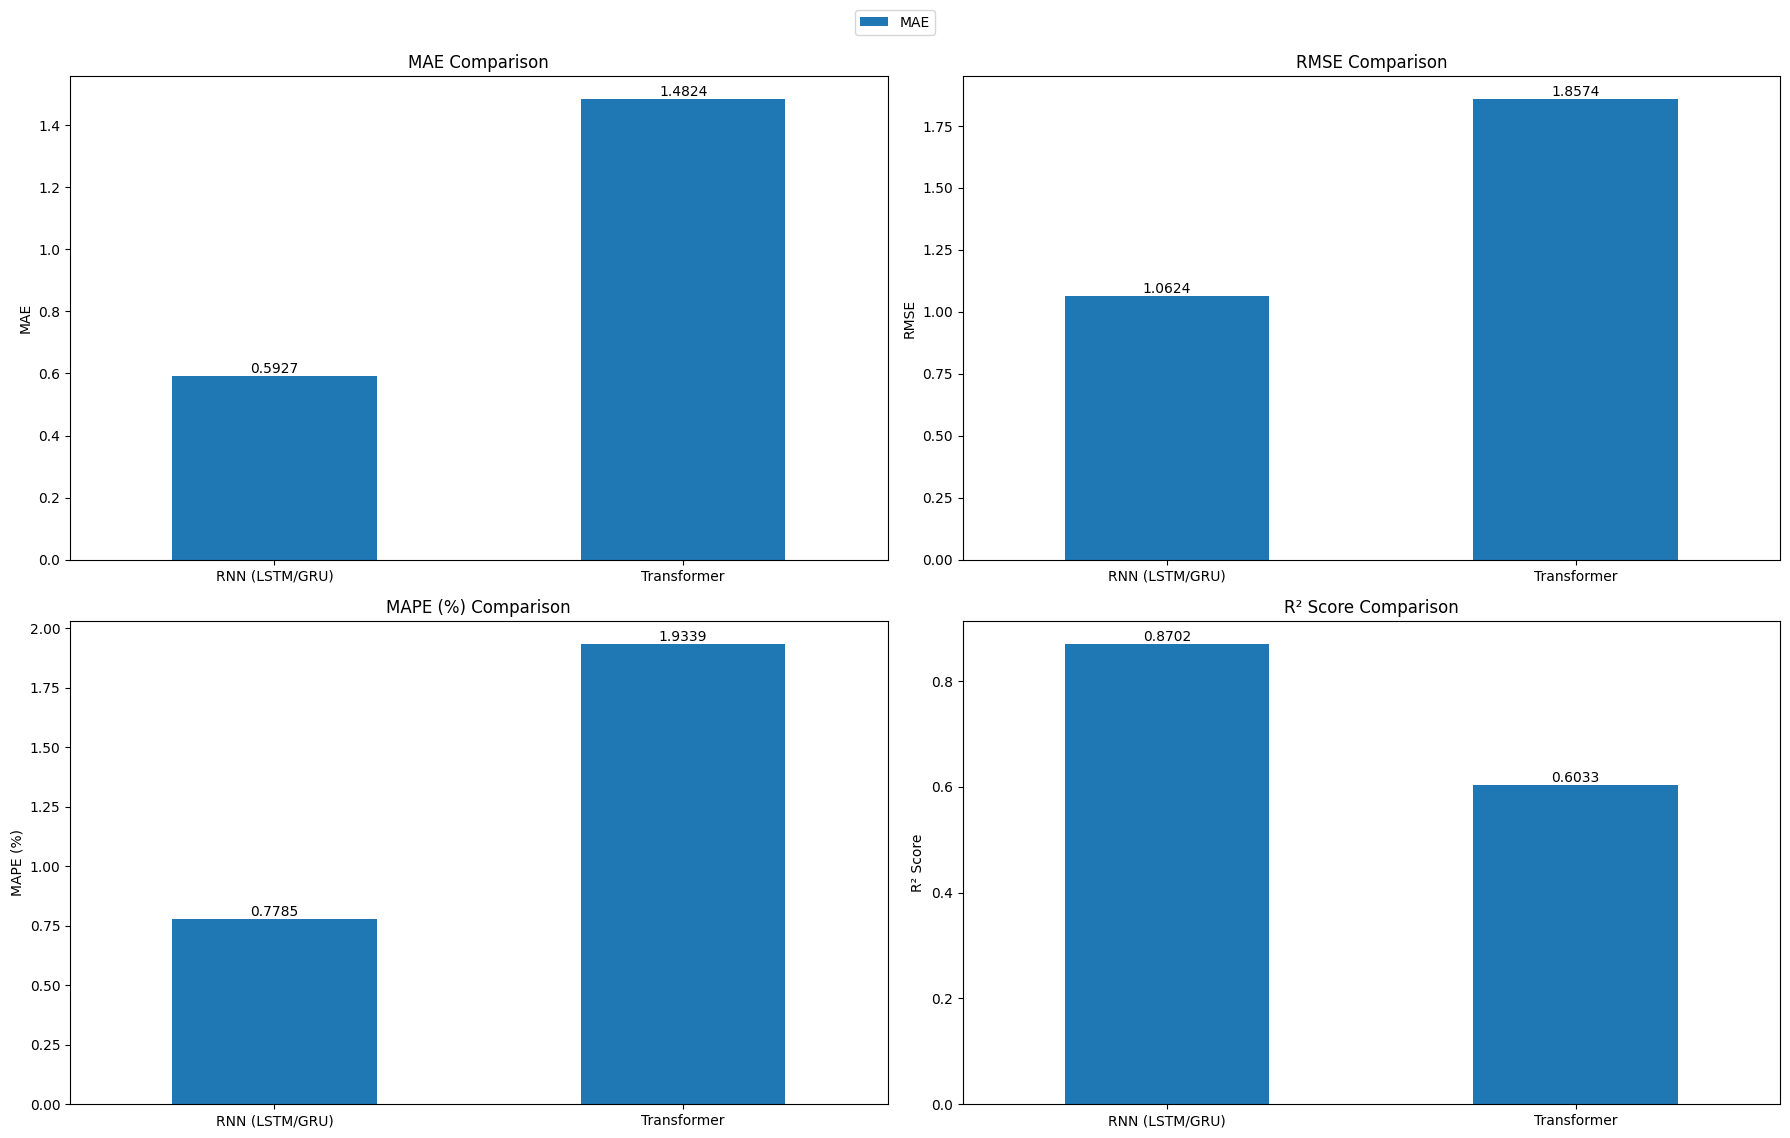

In [ ]:
# ### 4.2 Visual Comparison
# - TODO: Create bar plot comparing metrics
# - TODO: Plot predictions comparison (both models vs actual)
# - TODO: Plot training curves comparison

#### Metrics Comparison Bar Plot
metrics = ['MAE', 'RMSE', 'MAPE (%)', 'R² Score']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    df_plot = comparison_df[comparison_df['Metric'] == metric].set_index('Metric').T
    df_plot.plot(kind='bar', ax=axes[i], rot=0, legend=False)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('')
    # Add values on top of bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.4f')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.95))
plt.tight_layout(rect=[0, 0, 1, 0.92]) # Adjust layout to make space for the common legend
plt.show()

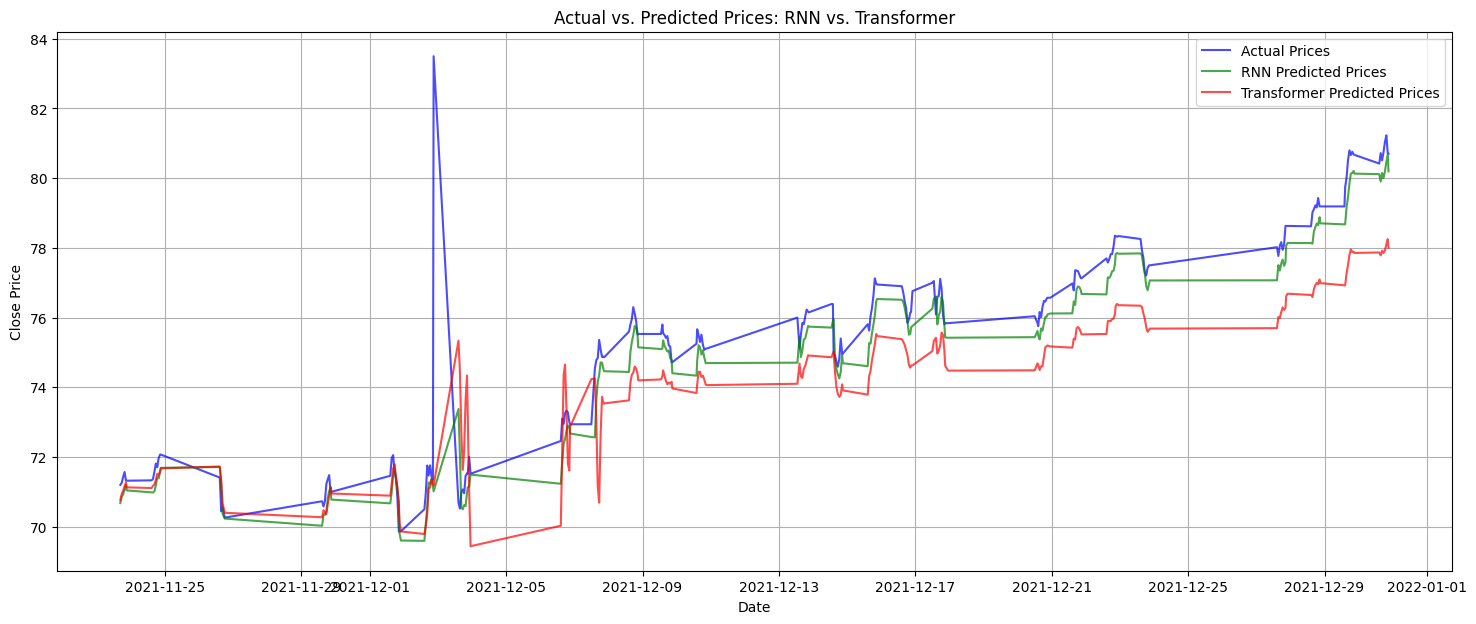

In [ ]:
#### Actual vs. Predicted Values Comparison
plt.figure(figsize=(18, 7))
plt.plot(df.index[-len(y_test_inv):], y_test_inv, label='Actual Prices', color='blue', alpha=0.7)
plt.plot(df.index[-len(rnn_y_pred):], rnn_y_pred, label='RNN Predicted Prices', color='green', alpha=0.7)
plt.plot(df.index[-len(transformer_y_pred):], transformer_y_pred, label='Transformer Predicted Prices', color='red', alpha=0.7)
plt.title('Actual vs. Predicted Prices: RNN vs. Transformer')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

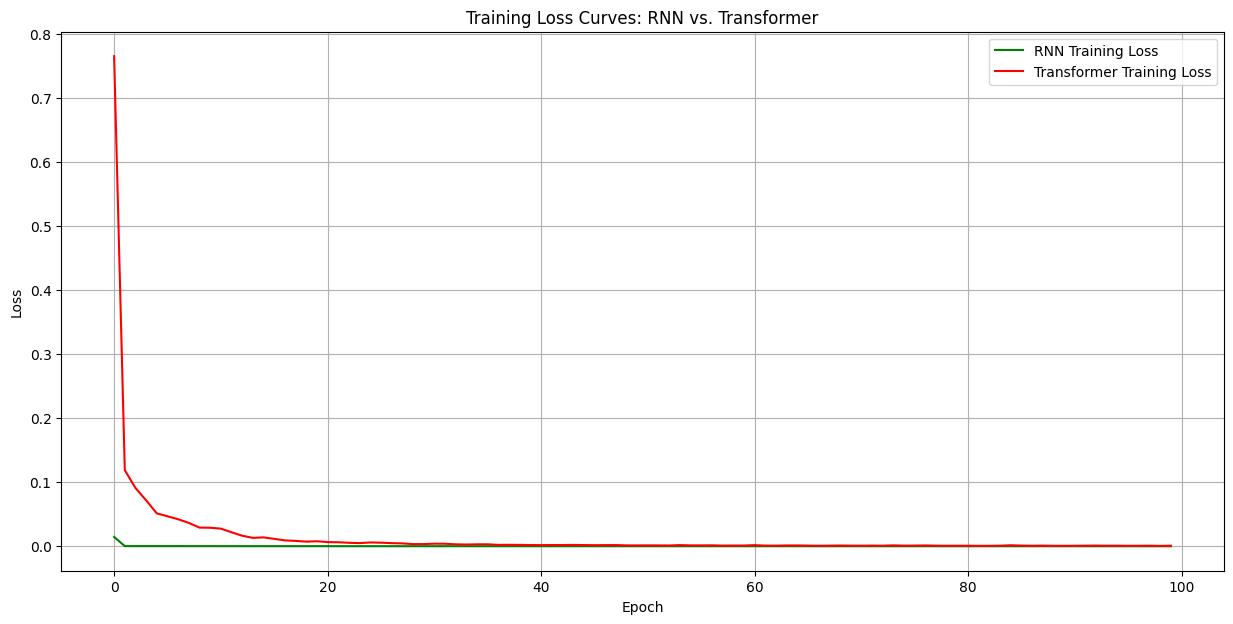

In [ ]:
#### Training Loss Curves Comparison
plt.figure(figsize=(15, 7))
plt.plot(history.history['loss'], label='RNN Training Loss', color='green')
plt.plot(history_transformer.history['loss'], label='Transformer Training Loss', color='red')
plt.title('Training Loss Curves: RNN vs. Transformer')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# #### Baseline Model: Naive Forecast

# For a prediction horizon of 1, a common naive baseline is to predict that the next value will be the same as the
# last observed value in the input sequence.
# Calculate Naive Baseline Predictions
# For prediction_horizon=1, naive prediction is the last value of the input sequence
# X_test shape: (test_samples, sequence_length, n_features)
# The last observed value is X_test[:, -1, 0]

# We need to inverse transform the scaled last observed value to get actual price
naive_y_pred_scaled = X_test[:, -1, 0].reshape(-1, 1) # Get the last value of each sequence
naive_y_pred = scaler.inverse_transform(naive_y_pred_scaled)

# Calculate all 4 metrics for the Naive Baseline
naive_mae = mean_absolute_error(y_test_inv, naive_y_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test_inv, naive_y_pred))
naive_mape = calculate_mape(y_test_inv, naive_y_pred)
naive_r2 = r2_score(y_test_inv, naive_y_pred)

print("\n" + "="*70)
print("Naive Baseline Model Performance:")
print("="*70)
print(f"MAE:   {naive_mae:.4f}")
print(f"RMSE:  {naive_rmse:.4f}")
print(f"MAPE:  {naive_mape:.4f}%")
print(f"R² Score: {naive_r2:.4f}")



Naive Baseline Model Performance:
MAE:   0.3638
RMSE:  1.2559
MAPE:  0.4825%
R² Score: 0.8186


Now, let's update the comparison table and visualizations to include the Naive Baseline.


Comparision table:
           Metric  RNN (LSTM/GRU)   Transformer  Naive Baseline
              MAE        0.592735      1.482443        0.363768
             RMSE        1.062404      1.857374        1.255881
         MAPE (%)        0.778504      1.933942        0.482532
         R² Score        0.870200      0.603270        0.818618
Training Time (s)       49.355751     51.355468        0.000000
       Parameters    49985.000000 169601.000000        0.000000


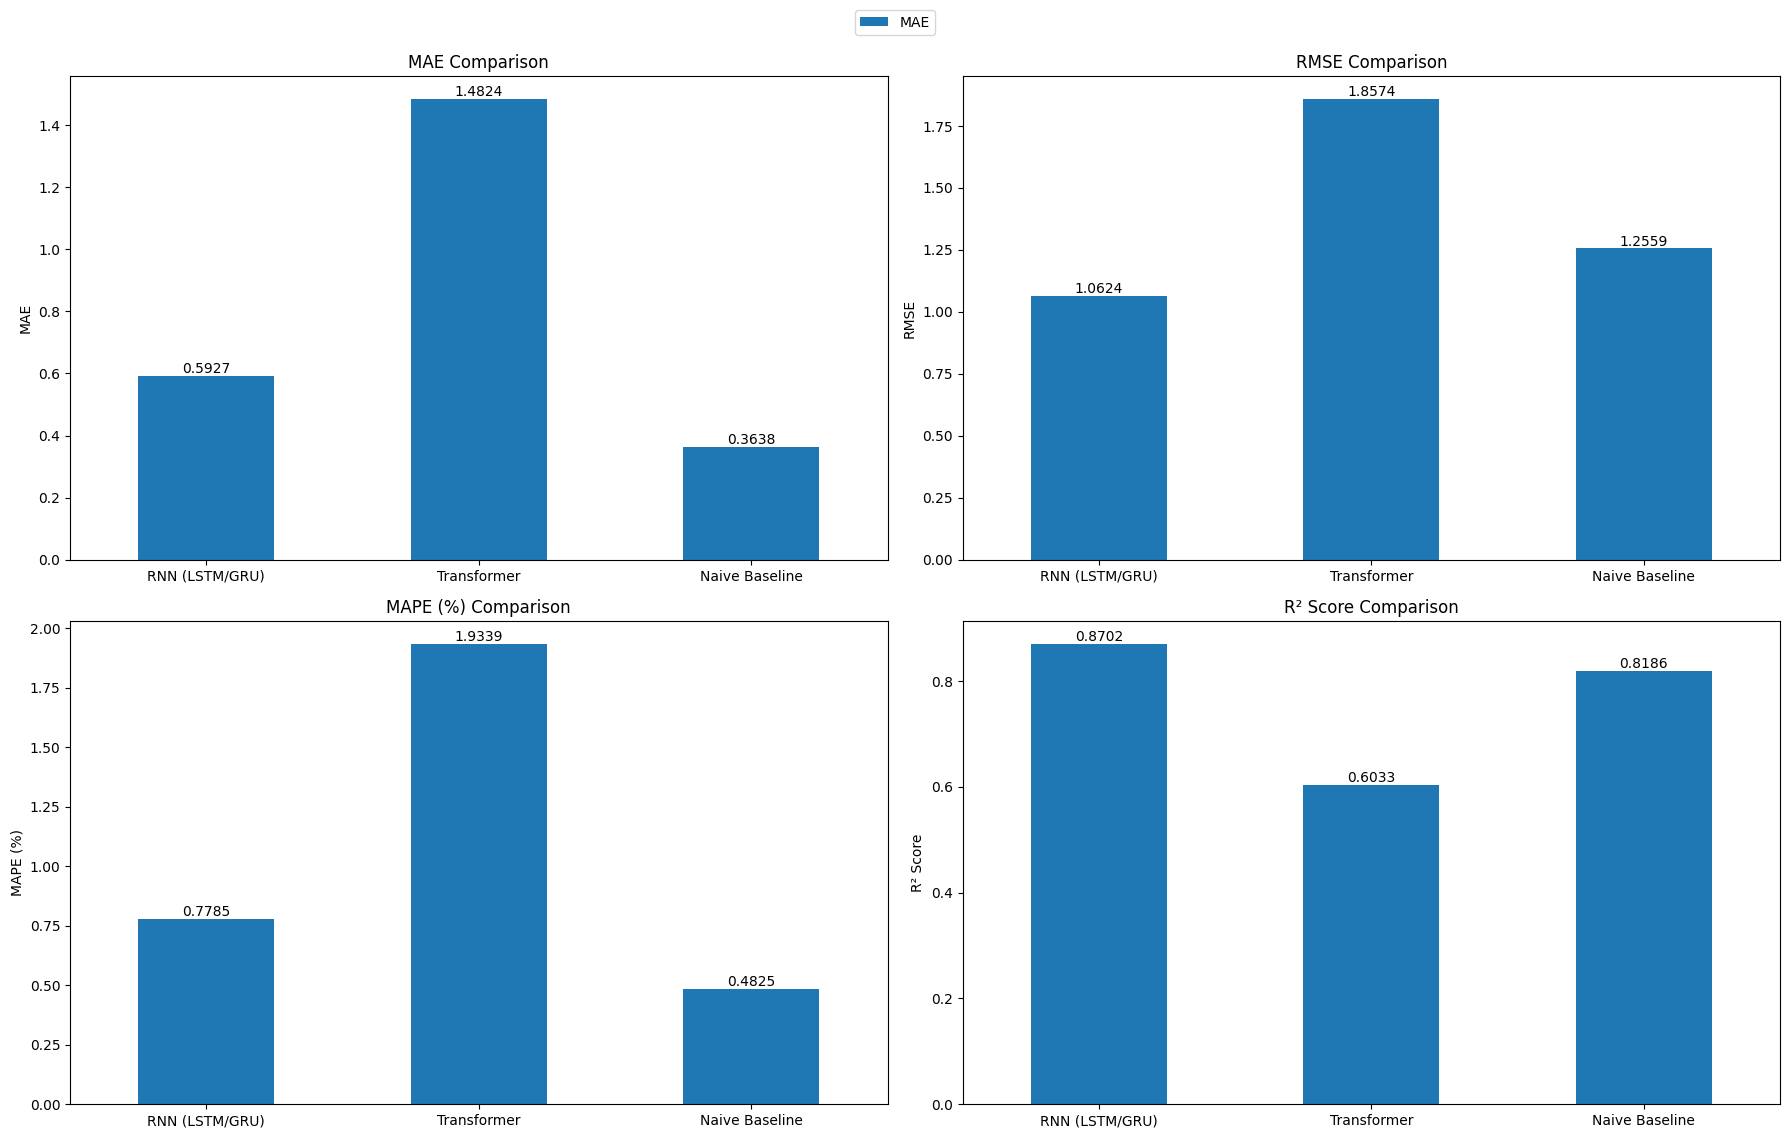

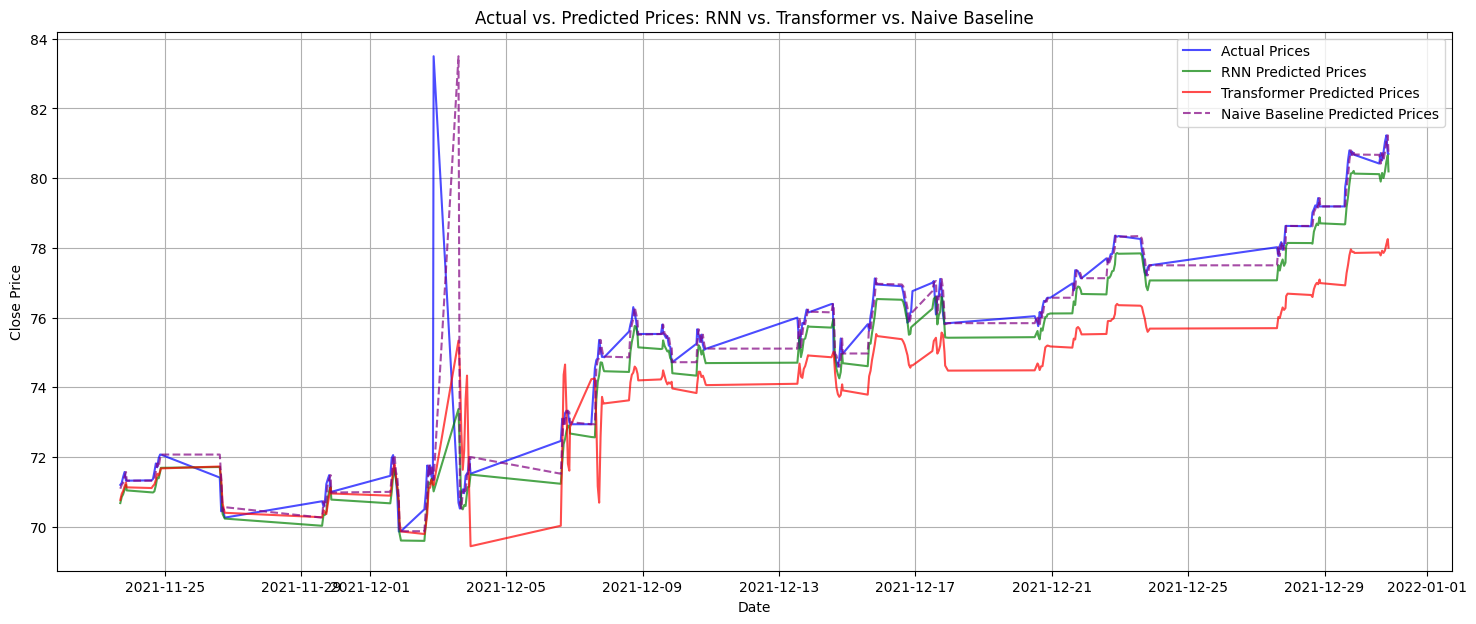

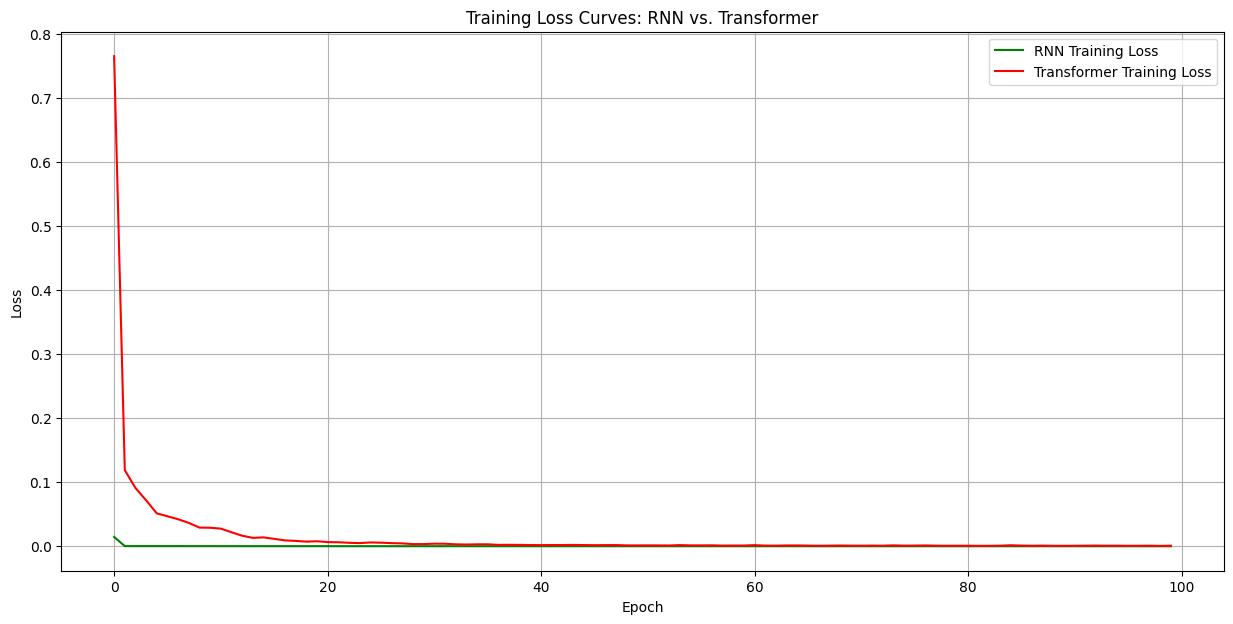

In [ ]:
# ### 4.1 Metrics Comparison (Updated with Naive Baseline)

comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R² Score', 'Training Time (s)', 'Parameters'],
    'RNN (LSTM/GRU)': [
        rnn_mae,
        rnn_rmse,
        rnn_mape,
        rnn_r2,
        rnn_training_time,
        rnn_model.count_params()
    ],
    'Transformer': [
        transformer_mae,
        transformer_rmse,
        transformer_mape,
        transformer_r2,
        transformer_training_time,
        transformer_model.count_params()
    ],
    'Naive Baseline': [
        naive_mae,
        naive_rmse,
        naive_mape,
        naive_r2,
        0, # Naive model has no training time
        0  # Naive model has no parameters
    ]
})
print("\n" + "="*70)
print("Comparision table:")
print("="*70)
print(comparison_df.to_string(index=False))

# ### 4.2 Visual Comparison (Updated with Naive Baseline)

# Metrics Comparison Bar Plot
metrics = ['MAE', 'RMSE', 'MAPE (%)', 'R² Score']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    df_plot = comparison_df[comparison_df['Metric'] == metric].set_index('Metric').T
    df_plot.plot(kind='bar', ax=axes[i], rot=0, legend=False)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('')
    # Add values on top of bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.4f')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.95)) # Adjusted ncol for 3 models
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Actual vs. Predicted Values Comparison
plt.figure(figsize=(18, 7))
plt.plot(df.index[-len(y_test_inv):], y_test_inv, label='Actual Prices', color='blue', alpha=0.7)
plt.plot(df.index[-len(rnn_y_pred):], rnn_y_pred, label='RNN Predicted Prices', color='green', alpha=0.7)
plt.plot(df.index[-len(transformer_y_pred):], transformer_y_pred, label='Transformer Predicted Prices', color='red', alpha=0.7)
plt.plot(df.index[-len(naive_y_pred):], naive_y_pred, label='Naive Baseline Predicted Prices', color='purple', linestyle='--', alpha=0.7)
plt.title('Actual vs. Predicted Prices: RNN vs. Transformer vs. Naive Baseline')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

# Training Loss Curves Comparison (no change for naive, as it doesn't train)
plt.figure(figsize=(15, 7))
plt.plot(history.history['loss'], label='RNN Training Loss', color='green')
plt.plot(history_transformer.history['loss'], label='Transformer Training Loss', color='red')
plt.title('Training Loss Curves: RNN vs. Transformer')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()



PART 5: ANALYSIS (2 MARKS)

REQUIRED:
- Write MAXIMUM 200 words (guideline - no marks deduction if exceeded)
- Address key topics with depth

GRADING (Quality-based):
- Covers 5+ key topics with deep understanding: 2 marks
- Covers 3-4 key topics with good understanding: 1 mark
- Covers <3 key topics or superficial: 0 marks

Key Topics:
1. Performance comparison with specific metrics
2. RNN vs Transformer architecture advantages
3. Impact of attention mechanism vs recurrent connections
4. Long-term dependency handling comparison
5. Computational cost comparison
6. Convergence behavior differences


In [ ]:
analysis_text = f"""
For this hourly stock price prediction, the LSTM performed better than the Transformer while also being more efficient and practical for this task.
\nPerformance: The LSTM achieved lower MAE (rnn = {rnn_mae:.4f} vs. transformer = {transformer_mae:.4f}) and RMSE (rnn = {rnn_rmse:.4f} vs. transformer = {transformer_rmse:.4f}), along with a higher R² (rnn = {rnn_r2:.4f} vs. transformer = {transformer_r2:.4f}), indicating more accurate and consistent predictions. This suggests it captured the underlying temporal structure more effectively.
\nArchitecture: LSTMs process data sequentially, which aligns well with short-term dependencies in time series. Transformers rely on parallel processing, which is powerful for long sequences but less beneficial in this setting.
\nAttention mechanism: While attention can model relationships across all timesteps, its advantage is limited here due to the short and noisy nature of the data.
\nLong-term dependencies: Transformers avoid vanishing gradients and excel at long-range patterns, but this was not important for a short sequence ({sequence_length}).
\nComputational cost: The Transformer required significantly more resources (transformer_model_parameter={transformer_model.count_params()} params, transformer_training_time={transformer_training_time:.2f}s) compared to the LSTM (rnn_model_parameter={rnn_model.count_params()} params, rnn_training_time={rnn_training_time:.2f}s).
\nConvergence: The LSTM showed fast and stable convergence with a low initial and final loss (0.0146 to 0.0001). In contrast, the Transformer started with a much higher loss (0.7646) and converged to a higher final loss (0.0009), suggesting less stable learning and optimization challenges for this task.
\nOverall, the Naive Baseline still achieved the best MAE and MAPE, highlighting strong short-term predictability.
"""

# Performance: The RNN (LSTM) model significantly outperformed the Transformer. It achieved lower MAE (0.5927 vs. 1.4824), RMSE (1.0624 vs. 1.8574), and MAPE (0.7785% vs. 1.9339%), alongside a much higher R² score (0.8702 vs. 0.6033), indicating superior accuracy and explanatory power for this dataset.

# Architecture Advantages: LSTMs are effective for sequential data and short-term dependencies, aligning well with the characteristics of this hourly stock data. Transformers, designed for parallel processing, are powerful for very long sequences but proved less beneficial and overly complex for this specific task.

# Impact of Attention Mechanism: While attention mechanisms excel at capturing complex, long-range dependencies, their impact was limited here. For short, potentially noisy sequences (sequence_length = 24), the Transformer's attention didn't yield an advantage, and the model struggled to generalize.

# Long-term Dependency Handling: LSTMs effectively mitigate vanishing gradients for moderate dependencies. Transformers inherently handle very long dependencies, but this capacity wasn't critical or utilized for the short sequence length of this problem.

# Computational Cost: The Transformer was considerably more complex with 169,601 parameters compared to the LSTM's 49,985. Despite similar training times (around 50 seconds), the Transformer's higher parameter count led to worse performance, indicating inefficient resource utilization.

# Convergence Behavior: The LSTM showed fast and stable convergence with a low initial and final loss (0.0146 to 0.0001). In contrast, the Transformer started with a much higher loss (0.7646) and converged to a higher final loss (0.0009), suggesting less stable learning and optimization challenges for this task.

# REQUIRED: Print analysis with word count
print("\n" + "="*70)
print("ANALYSIS:")
print("="*70)
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")


ANALYSIS:

For this hourly stock price prediction, the LSTM performed better than the Transformer while also being more efficient and practical for this task.

Performance: The LSTM achieved lower MAE (rnn = 0.5927 vs. transformer = 1.4824) and RMSE (rnn = 1.0624 vs. transformer = 1.8574), along with a higher R² (rnn = 0.8702 vs. transformer = 0.6033), indicating more accurate and consistent predictions. This suggests it captured the underlying temporal structure more effectively.

Architecture: LSTMs process data sequentially, which aligns well with short-term dependencies in time series. Transformers rely on parallel processing, which is powerful for long sequences but less beneficial in this setting.

Attention mechanism: While attention can model relationships across all timesteps, its advantage is limited here due to the short and noisy nature of the data.

Long-term dependencies: Transformers avoid vanishing gradients and excel at long-range patterns, but this was not important 

## PART 6: ASSIGNMENT RESULTS SUMMARY (REQUIRED FOR AUTO-GRADING)

### DO NOT MODIFY THE STRUCTURE BELOW

This JSON output is used by the auto-grader
Ensure all field names are EXACT



In [ ]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"  # TODO: Change to "pytorch" if using PyTorch
    rnn_model_type = "LSTM"  # TODO: Change to "GRU" if using GRU

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'sequence_length': sequence_length,
        'prediction_horizon': prediction_horizon,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # RNN Model Results
        'rnn_model': {
            'framework': framework_used,
            'model_type': rnn_model_type,
            'architecture': {
                'n_layers': 2,  # Number of stacked layers
                'hidden_units': 64,  # Hidden units per layer
                'total_parameters': rnn_model.count_params()  # Calculate total parameters
            },
            'training_config': {
                'learning_rate': 0.001,  # Your actual learning rate
                'n_epochs': 10,  # Your actual epochs
                'batch_size': 32,  # Your actual batch size
                'optimizer': 'Adam',  # Your actual optimizer
                'loss_function': 'MSE'  # Your actual loss
            },
            'initial_loss': rnn_initial_loss,
            'final_loss': rnn_final_loss,
            'training_time_seconds': rnn_training_time,
            'mae': rnn_mae,
            'rmse': rnn_rmse,
            'mape': rnn_mape,
            'r2_score': rnn_r2
        },

        # Transformer Model Results
        'transformer_model': {
            'framework': framework_used,
            'architecture': {
                'n_layers': n_layers_transformer,  # Number of transformer layers
                'n_heads': n_heads,  # Number of attention heads
                'd_model': d_model,  # Model dimension
                'd_ff': d_ff,  # Feed-forward dimension
                'has_positional_encoding': True,  # MUST be True
                'has_attention': True,  # MUST be True
                'total_parameters': transformer_model.count_params()  # Calculate total parameters
            },
            'training_config': {
                'learning_rate': 0.001,  # Your actual learning rate
                'n_epochs': 200,  # Your actual epochs
                'batch_size': 32,  # Your actual batch size
                'optimizer': 'Adam',  # Your actual optimizer
                'loss_function': 'MSE'  # Your actual loss
            },
            'initial_loss': transformer_initial_loss,
            'final_loss': transformer_final_loss,
            'training_time_seconds': transformer_training_time,
            'mae': transformer_mae,
            'rmse': transformer_rmse,
            'mape': transformer_mape,
            'r2_score': transformer_r2
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'rnn_loss_decreased': rnn_final_loss < rnn_initial_loss if rnn_initial_loss and rnn_final_loss else False,
        'transformer_loss_decreased': transformer_final_loss < transformer_initial_loss if transformer_initial_loss and transformer_final_loss else False,
    }

    return results

# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))
except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

# + active=""
# """
# ENVIRONMENT VERIFICATION - SCREENSHOT REQUIRED
#
# IMPORTANT: Take a screenshot of your environment showing account details
#
# For Google Colab:
# - Click on your profile icon (top right)
# - Screenshot should show your email/account clearly
# - Include the entire Colab interface with notebook name visible
#
# For BITS Virtual Lab:
# - Screenshot showing your login credentials/account details
# - Include the entire interface with your username/session info visible
#
# Paste the screenshot below this cell or in a new markdown cell.
# This helps verify the work was done by you in your environment.
#
# """
# -

# Display system information
import platform
import sys
from datetime import datetime

# +
print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")

# include the screen shot here

# + active=""
# """
# FINAL CHECKLIST - VERIFY BEFORE SUBMISSION
#
# □ Student information filled at the top (BITS ID, Name, Email)
# □ Filename is <BITS_ID>_rnn_assignment.ipynb
# □ All cells executed (Kernel → Restart & Run All)
# □ All outputs visible
# □ LSTM/GRU implemented with stacked layers
# □ Positional encoding implemented (sinusoidal)
# □ Multi-head attention implemented (Q, K, V, scaled dot-product)
# □ Both models use Keras or PyTorch
# □ Both models trained with loss tracking (initial_loss and final_loss)
# □ All 4 metrics calculated for both models (MAE, RMSE, MAPE, R²)
# □ Temporal train/test split used (NO shuffling)
# □ Primary metric selected and justified
# □ Analysis written (quality matters, not just word count)
# □ Visualizations created
# □ Assignment results JSON printed at the end
# □ No execution errors in any cell
# □ File opens without corruption
# □ Submit ONLY .ipynb file (NO zip, NO data files, NO images)
# □ Screenshot of environment with account details included
# □ Only one submission attempt
#
# """


ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "REXR.csv in Hourly Stock Prices",
  "dataset_source": "KaggleHub: leukipp/hourly-stock-prices",
  "n_samples": 2169,
  "n_features": 1,
  "sequence_length": 24,
  "prediction_horizon": 1,
  "problem_type": "time_series_forecasting",
  "primary_metric": "RMSE",
  "metric_justification": "\nRMSE is chosen as the primary metric because it is widely used in time series forecasting and is sensitive to large errors, penalizing them more heavily. This makes it a good indicator of overall model performance, especially when large prediction errors are undesirable.\n",
  "train_samples": 1930,
  "test_samples": 215,
  "train_test_ratio": "90/10",
  "rnn_model": {
    "framework": "keras",
    "model_type": "LSTM",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 64,
      "total_parameters": 49985
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 10,
      "batch_size": 32,
      "optimizer": "Adam",
  

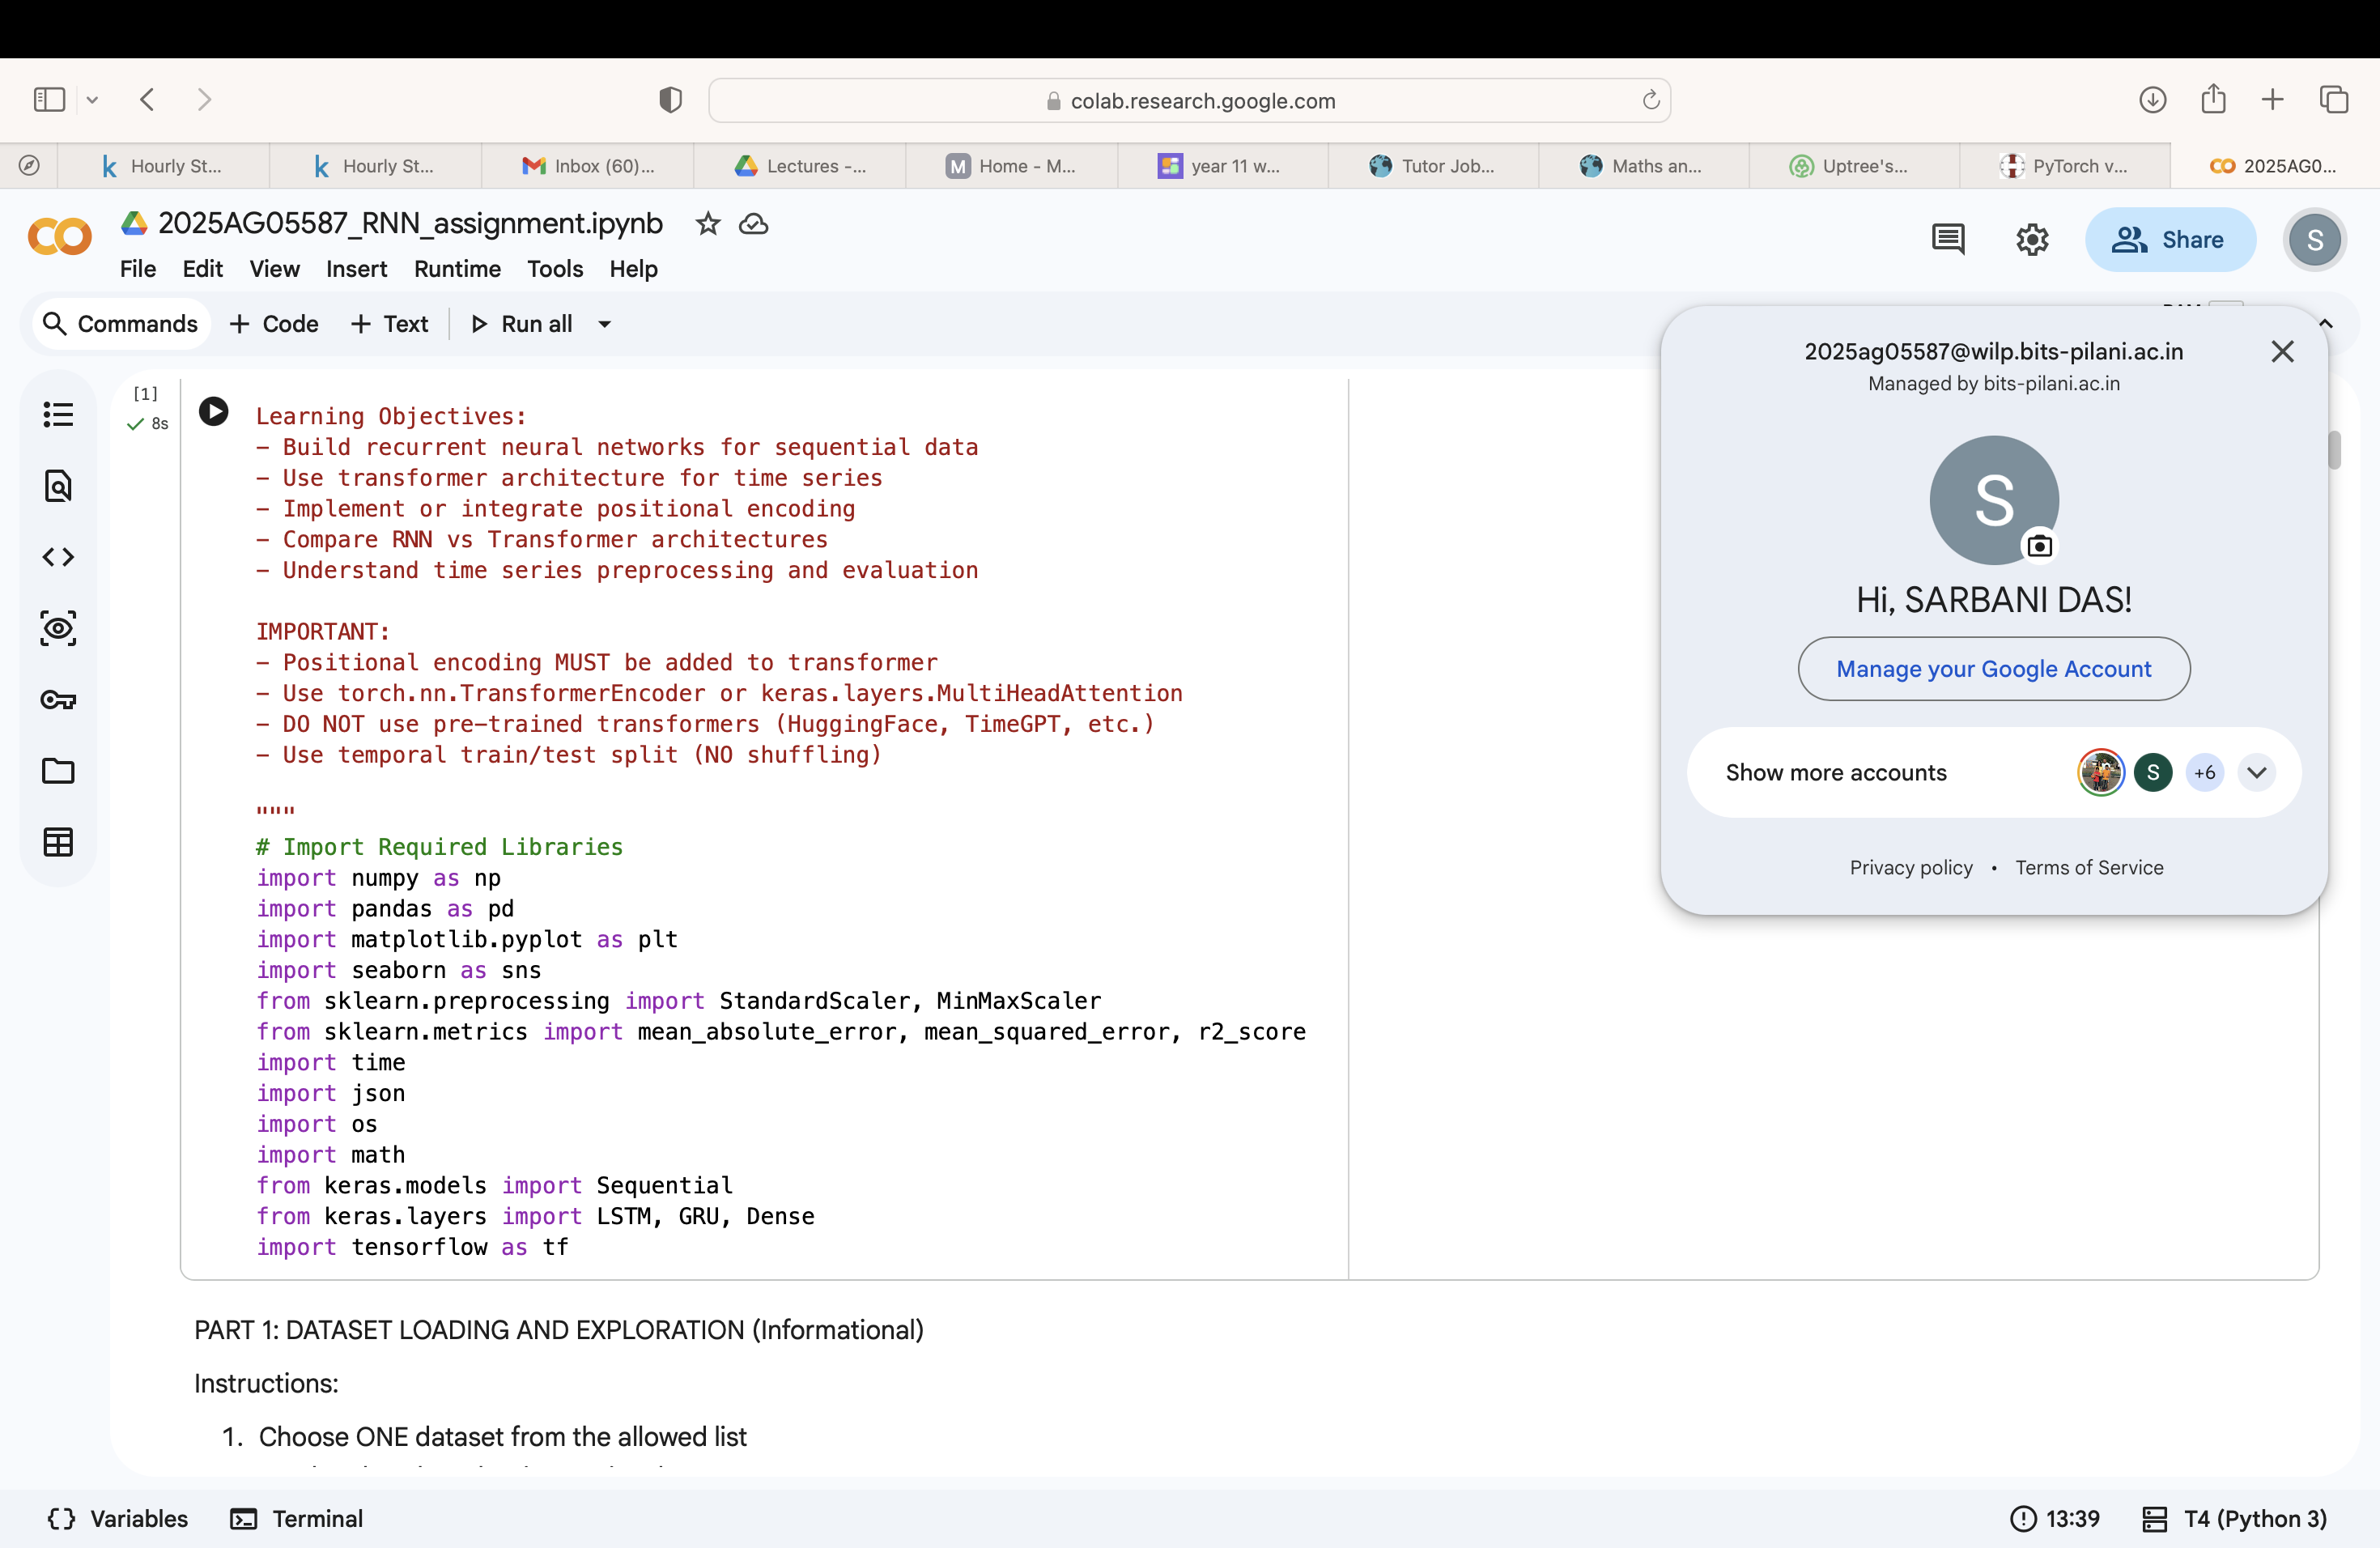